In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

In [ ]:
max_features = 10000
maxlen = 500
batch_size = 64

print('Loading data...')
(input_train, y_train), (input_test, y_test) = imdb.load_data(num_words=max_features)
print(len(input_train), 'train sequences')
print(len(input_test), 'test sequences')

print('Pad sequences (samples x time)')
input_train = sequence.pad_sequences(input_train, maxlen=maxlen)
input_test = sequence.pad_sequences(input_test, maxlen=maxlen)
print('input_train shape:', input_train.shape)
print('input_test shape:', input_test.shape)

Loading data...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
25000 train sequences
25000 test sequences
Pad sequences (samples x time)
input_train shape: (25000, 500)
input_test shape: (25000, 500)


In [ ]:
def build_and_train(model_type='RNN'):
    model = Sequential()
    model.add(Embedding(max_features, 32))
    if model_type == 'RNN':
        model.add(SimpleRNN(32))
    elif model_type == 'LSTM':
        model.add(LSTM(32))
    elif model_type == 'GRU':
        model.add(GRU(32))

    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

    print(f'\nTraining {model_type} model...')
    history = model.fit(input_train, y_train, epochs=5, batch_size=batch_size, validation_split=0.2, verbose=1)
    return history

rnn_history = build_and_train('RNN')
lstm_history = build_and_train('LSTM')
gru_history = build_and_train('GRU')


Training RNN model...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 130ms/step - acc: 0.6835 - loss: 0.5726 - val_acc: 0.8020 - val_loss: 0.4379
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 48ms/step - acc: 0.8488 - loss: 0.3593 - val_acc: 0.8474 - val_loss: 0.3567
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - acc: 0.8799 - loss: 0.2941 - val_acc: 0.8422 - val_loss: 0.3509
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - acc: 0.9050 - loss: 0.2441 - val_acc: 0.8564 - val_loss: 0.3373
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - acc: 0.9223 - loss: 0.2062 - val_acc: 0.8514 - val_loss: 0.4131

Training LSTM model...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - acc: 0.7193 - loss: 0.5331 - val_acc: 0.8482 - val_loss: 0.3692
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - acc: 0.8626 - loss: 0.3379 - val_acc: 0.8692 - val_loss: 0.3145
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - acc: 0.8884 - loss: 0.2827 - val_acc: 0.8626 - val_loss: 0.3208
Ep

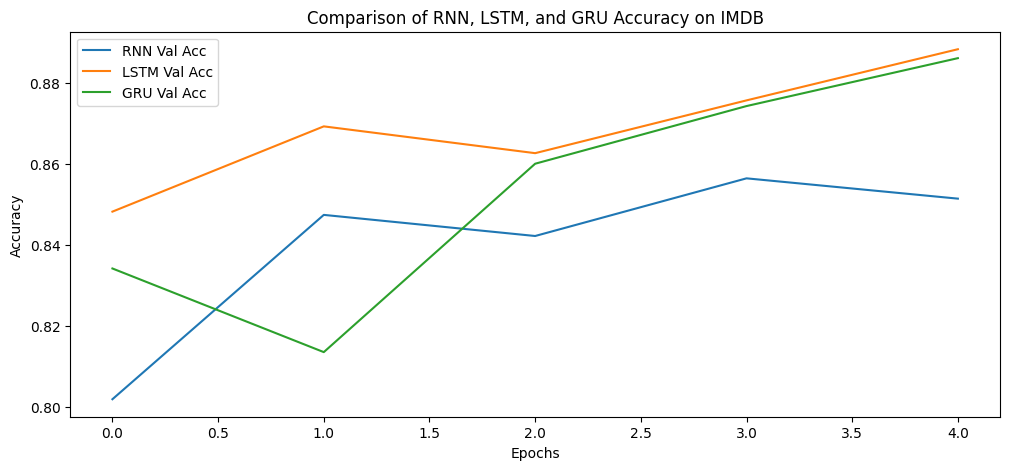

In [ ]:
def plot_history(histories, title):
    plt.figure(figsize=(12, 5))
    for name, history in histories.items():
        plt.plot(history.history['val_acc'], label=f'{name} Val Acc')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

histories = {'RNN': rnn_history, 'LSTM': lstm_history, 'GRU': gru_history}
plot_history(histories, 'Comparison of RNN, LSTM, and GRU Accuracy on IMDB')